In [2]:
import thread_lorentz 
import matplotlib.pyplot as plt
import numpy as np
import time
import timeit
# Automated histogram plot settings
xmin, xmax = -10, 10
num_bins = 100

def plot_histogram(counts, xmin=xmin, xmax=xmax, num_bins=num_bins):
    # Map bin counts to x-range [-10, 10]
    bin_width = (xmax - xmin) / num_bins
    x_left_edges = [xmin + i * bin_width for i in range(num_bins)]

    plt.figure(figsize=(10, 4))
    plt.bar(x_left_edges, counts, width=bin_width, align="edge", edgecolor="black")
    plt.xlim(xmin, xmax)
    plt.title(f"Histogram (x from {xmin} to {xmax}, {num_bins} bins)")
    plt.xlabel("x")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()



Time taken with 1 threads: 3.0720 seconds
Time taken with 2 threads: 1.8773 seconds
Time taken with 4 threads: 1.4212 seconds
Time taken with 8 threads: 0.7501 seconds
Time taken with 16 threads: 0.8798 seconds
Time taken with 32 threads: 0.8012 seconds


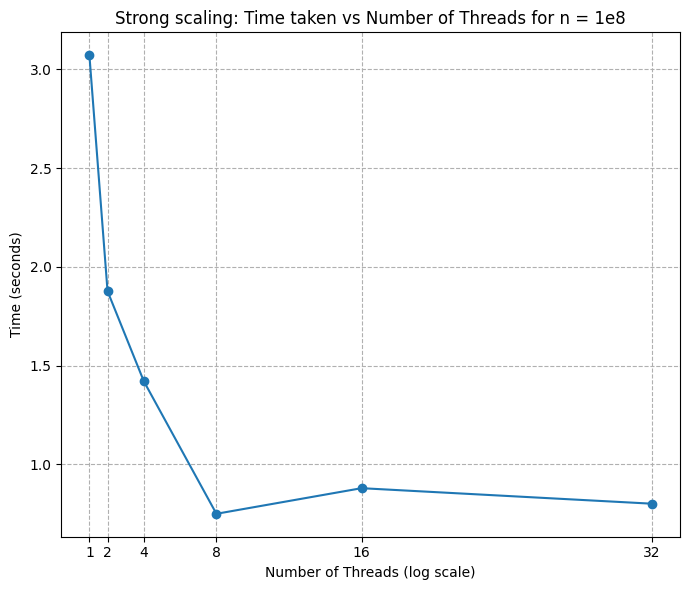

In [2]:
#Strong Scaling
n=1e8
times=[]
thread_counts = [1, 2, 4, 8, 16, 32]
for n_threads in thread_counts:
    start_time = time.perf_counter()
    local_counts,cnt = thread_lorentz.run_threaded(n, n_threads=n_threads)
    end_time = time.perf_counter()
    thread_time =  end_time - start_time
    times.append(thread_time)
    print(f"Time taken with {cnt} threads: {end_time - start_time:.4f} seconds")


#plot_histogram(local_counts)

plt.figure(figsize=(7, 6))
plt.plot(thread_counts, times, marker='o')
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Time (seconds)')
plt.title(f'Strong scaling: Time taken vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

Time taken with 1 threads: 2.7241 seconds
Time taken with 2 threads: 4.0008 seconds
Time taken with 4 threads: 10.4013 seconds
Time taken with 8 threads: 48.8498 seconds
Time taken with 16 threads: 183.2114 seconds


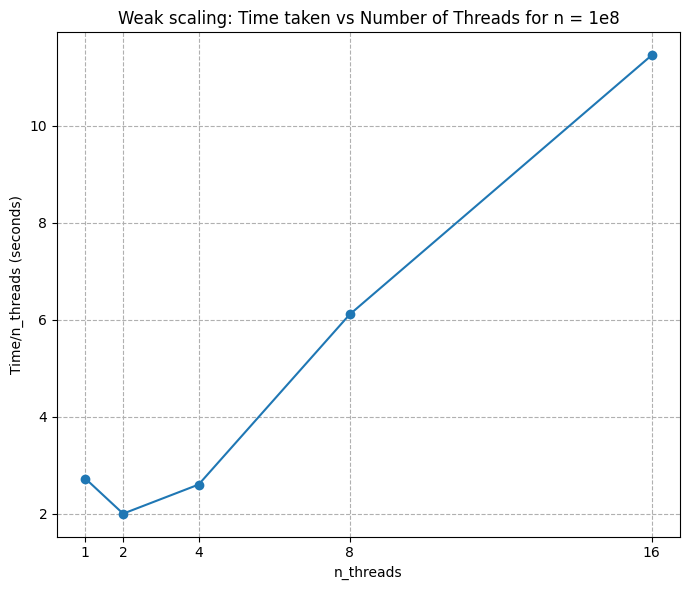

In [3]:
#Weak Scaling
n=1e8
times=[]
thread_counts = [1, 2, 4, 8, 16]
for n_threads in thread_counts:
    start_time = time.perf_counter()
    local_counts,cnt = thread_lorentz.run_threaded(n*n_threads, n_threads=n_threads)
    end_time = time.perf_counter()
    thread_time =  end_time - start_time
    times.append(thread_time/n_threads)  # Normalize by number of threads for weak scaling
    print(f"Time taken with {cnt} threads: {end_time - start_time:.4f} seconds")


#plot_histogram(local_counts)

plt.figure(figsize=(7, 6))
plt.plot(thread_counts, times, marker='o')
plt.xlabel('n_threads')
plt.ylabel('Time/n_threads (seconds)')
plt.title(f'Weak scaling: Time taken vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

# Multiprocessing module

Time taken with 1 threads: 0.1729 seconds
Time taken with 2 threads: 0.2068 seconds
Time taken with 4 threads: 0.3552 seconds
Time taken with 6 threads: 0.4416 seconds
Time taken with 1 threads: 0.3645 seconds
Time taken with 2 threads: 0.3502 seconds
Time taken with 4 threads: 0.3829 seconds
Time taken with 6 threads: 0.4589 seconds
Time taken with 1 threads: 2.6731 seconds
Time taken with 2 threads: 1.2607 seconds
Time taken with 4 threads: 0.8594 seconds
Time taken with 6 threads: 0.9013 seconds


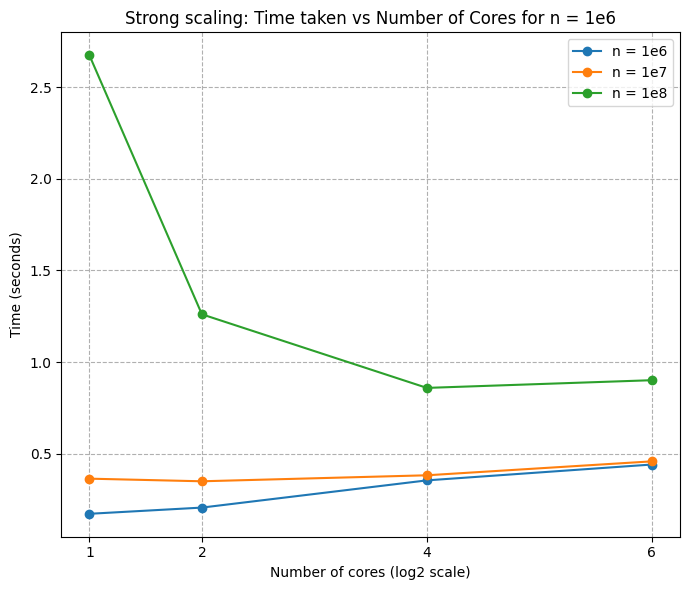

In [13]:
import mp_lorentz

import matplotlib.pyplot as plt

#Strong Scaling
n=[1e6, 1e7, 1e8]
repeats = 5
thread_counts = [1, 2, 3, 4, 6]
times = np.zeros((len(n), len(thread_counts)))
for i, n_val in enumerate(n):
    n_val = int(n_val)
    local_counts = mp_lorentz.run_multiproc(n_val, n_cores=1)  # Run once to warm up
    for j, n_threads in enumerate(thread_counts):
        avg_time = timeit.timeit(lambda: mp_lorentz.run_multiproc(n_val, n_cores= n_threads), number =repeats )/repeats
        times[i, j] = avg_time
        print(f"Time taken with {n_threads} threads: {avg_time:.4f} seconds")


#plot_histogram(local_counts)

plt.figure(figsize=(7, 6))
for i, n_val in enumerate(n):
    plt.plot(thread_counts, times[i,:], marker='o', label=f'n = 1e{int(np.log10(n_val))}')
plt.xlabel('Number of cores (log2 scale)')
plt.ylabel('Time (seconds)')
plt.title(f'Strong scaling: Time taken vs Number of Cores for n = 1e{int(np.log10(n[0]))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.legend()
plt.tight_layout()
plt.show()

python(6110) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Time taken with 1 threads: 0.3179 seconds


python(6111) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6112) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Time taken with 2 threads: 0.4182 seconds


python(6117) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6118) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6119) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6120) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Time taken with 4 threads: 0.4882 seconds


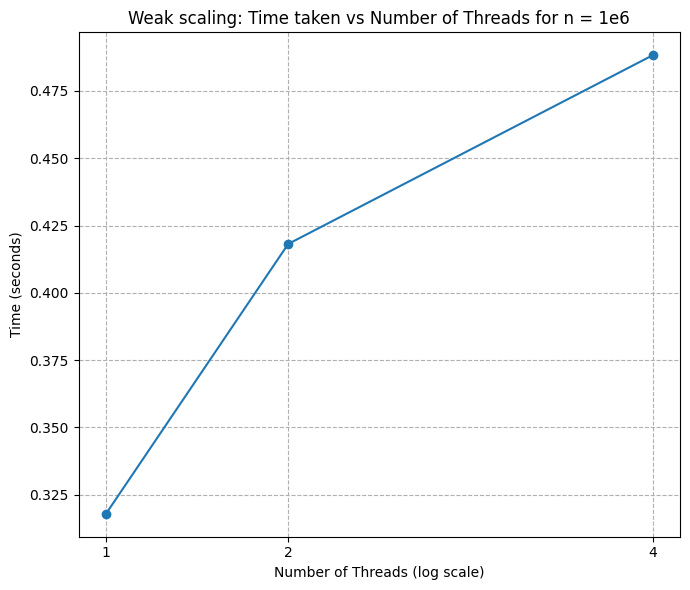

In [5]:
#Weak Scaling
n=1e6
times=[]
thread_counts = [1, 2, 4]
for n_threads in thread_counts:
    start_time = time.perf_counter()
    local_counts = mp_lorentz.run_multiproc(n*n_threads, n_cores=n_threads)
    end_time = time.perf_counter()
    thread_time =  end_time - start_time
    times.append(thread_time)
    print(f"Time taken with {n_threads} threads: {end_time - start_time:.4f} seconds")


#plot_histogram(local_counts)

plt.figure(figsize=(7, 6))
plt.plot(thread_counts, times, marker='o')
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Time (seconds)')
plt.title(f'Weak scaling: Time taken vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

# ProcessPoolExecuter : concurrent.features

Time taken with 1 workers: 0.1950 seconds
Time taken with 2 workers: 0.3367 seconds
Time taken with 3 workers: 0.3723 seconds
Time taken with 4 workers: 0.4002 seconds
Time taken with 1 workers: 0.4324 seconds
Time taken with 2 workers: 0.4362 seconds
Time taken with 3 workers: 0.4276 seconds
Time taken with 4 workers: 0.4458 seconds
Time taken with 1 workers: 2.9307 seconds
Time taken with 2 workers: 1.7575 seconds
Time taken with 3 workers: 1.5659 seconds
Time taken with 4 workers: 1.0958 seconds
Time taken with 1 workers: 9.0280 seconds
Time taken with 2 workers: 5.0809 seconds
Time taken with 3 workers: 4.6391 seconds
Time taken with 4 workers: 4.0833 seconds


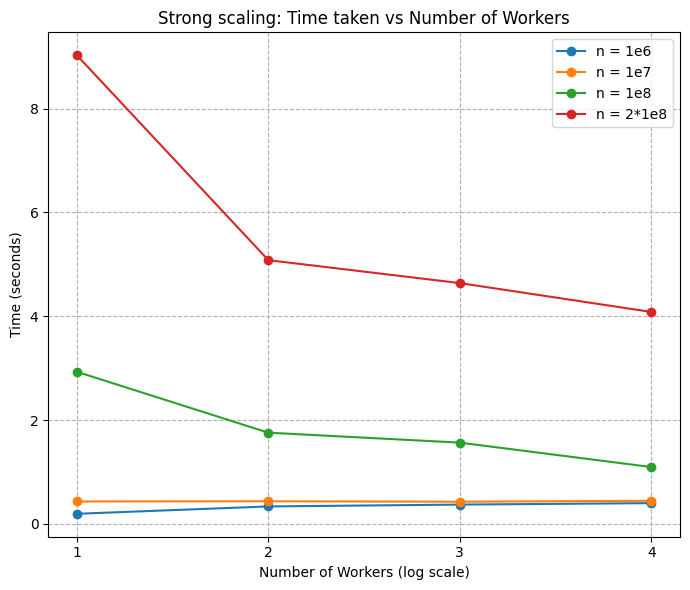

In [4]:
import ppe_lorentz
import numpy as np
#Strong Scaling
n=[1e6, 1e7, 1e8, 2*1e8]
repeats = 5
worker_counts = [1, 2, 3, 4]
times=np.zeros((len(n), len(worker_counts)))

for i, n_val in enumerate(n):
    n_val = int(n_val)
    local_counts = ppe_lorentz.run_ppe(n_val, max_workers=1)  # Run once to warm up
    for j, n_workers in enumerate(worker_counts):
        avg_time = timeit.timeit(lambda: ppe_lorentz.run_ppe(n_val, max_workers=n_workers), number=repeats)/repeats
        times[i,j] = avg_time
        print(f"Time taken with {n_workers} workers: {avg_time:.4f} seconds", flush=True)
    


plt.figure(figsize=(7, 6))
for i, n_val in enumerate(n):
    if n_val == 2*1e8:
        plt.plot(worker_counts, times[i,:], marker='o', label=f'n = 2*1e8')
        continue  # Skip the last point for better visualization
    plt.plot(worker_counts, times[i,:], marker='o', label=f'n = 1e{int(np.log10(n_val))}')
plt.xlabel('Number of Workers (log scale)')
plt.ylabel('Time (seconds)')
plt.title('Strong scaling: Time taken vs Number of Workers')
plt.grid(True, which="both", ls="--")
plt.xticks(worker_counts, worker_counts)
plt.legend()
plt.tight_layout()
plt.show()  


# asyncio

Time taken with 1 workers: 0.9406 seconds
Time taken with 2 workers: 0.8253 seconds
Time taken with 4 workers: 0.8548 seconds
Time taken with 8 workers: 0.7362 seconds
Time taken with 1 workers: 99.4781 seconds
Time taken with 2 workers: 43.1959 seconds
Time taken with 4 workers: 16.0421 seconds
Time taken with 8 workers: 7.3716 seconds


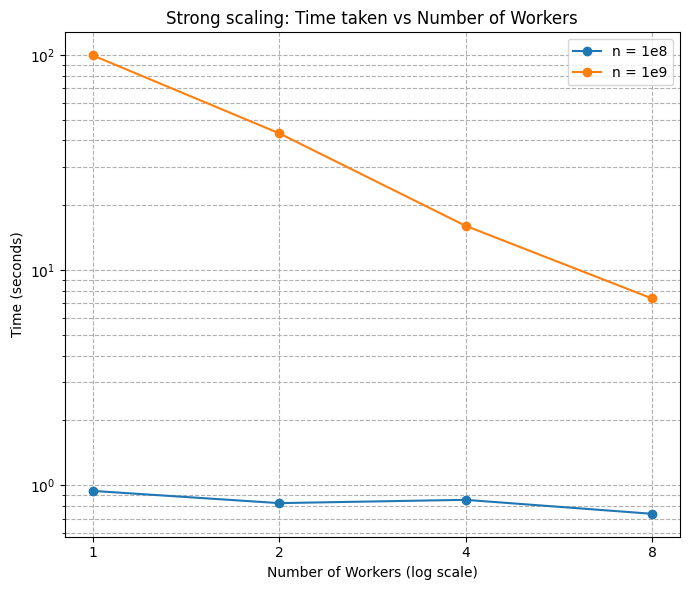

In [6]:
import async_lorentz
import asyncio

#Strong Scaling
n=[1e8, 1e9]
repeats = 5
worker_counts = [1, 2, 4, 8]
times=np.zeros((len(n), len(worker_counts)))

for i, n_val in enumerate(n):
    n_val = int(n_val)
    local_counts = await async_lorentz.get_counts(n_val, n_tasks=1)  # Run once to warm up
    for j, n_workers in enumerate(worker_counts):
        start_time = time.perf_counter()
        local_counts = await async_lorentz.get_counts(n_val, n_tasks=n_workers,n_subchunks=10)
        end_time = time.perf_counter()
        times[i,j] = end_time - start_time
        print(f"Time taken with {n_workers} workers: {times[i,j]:.4f} seconds", flush=True)
    


plt.figure(figsize=(7, 6))
for i, n_val in enumerate(n):
    if n_val == 2*1e8:
        plt.plot(worker_counts, times[i,:], marker='o', label=f'n = 2*1e8')
        continue  # Skip the last point for better visualization
    plt.plot(worker_counts, times[i,:], marker='o', label=f'n = 1e{int(np.log10(n_val))}')
plt.xlabel('Number of Workers (log scale)')
plt.ylabel('Time (seconds)')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.title('Strong scaling: Time taken vs Number of Workers')
plt.grid(True, which="both", ls="--")
plt.xticks(worker_counts, worker_counts)
plt.legend()
plt.tight_layout()
plt.show()  


CPU times: user 4 μs, sys: 1 μs, total: 5 μs
Wall time: 200 μs
